# 1. Geração de Data set IMDB

### 1.1. 🚀 Instalação e Importação de Bibliotecas Essenciais

- **Prepara o ambiente**: Instala bibliotecas cruciais como `Tesseract`, `pytesseract`, `wordcloud` e `deep_translator`.
- **Importa módulos**: Módulos como `os`, `numpy`, `tensorflow`, `matplotlib.pyplot`, `pandas`, `PIL.Image`, `keras` (datasets, layers, models, preprocessing), `google.colab.files`, `wordcloud.WordCloud`, `deep_translator.GoogleTranslator` e `IPython.display` são importados para o projeto.

In [56]:
# 1. INSTALAÇÃO E IMPORTS (COM TRADUTOR)
# Instala Tesseract OCR (para reconhecimento de texto em imagens)
!apt-get install tesseract-ocr -y
# Instala bibliotecas Python: pytesseract (interface para Tesseract), wordcloud (cria nuvens de palavras) e deep_translator (para tradução)
!pip install pytesseract wordcloud deep_translator

# Importa módulos essenciais
import os # Funções do sistema operacional
import numpy as np # Computação numérica (arrays)
import tensorflow as tf # Framework de Machine Learning (IA)
import matplotlib.pyplot as plt # Criação de gráficos e visualizações
import pandas as pd # Manipulação e análise de dados (DataFrames)
from PIL import Image # Processamento de imagens
# Keras: Datasets (para carregar o IMDB), layers (camadas da rede neural), models (construção do modelo), preprocessing (pré-processamento de dados)
from tensorflow.keras import datasets, layers, models, preprocessing
from google.colab import files # Funcionalidades de arquivo específicas do Google Colab
from wordcloud import WordCloud # Geração de nuvens de palavras
from deep_translator import GoogleTranslator
from IPython.display import display, clear_output # Utilidades do Colab para exibição e limpeza de saída

# Silencia avisos do TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
print("✅ Ambiente configurado com Suporte a Tradução (PT -> EN)!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
✅ Ambiente configurado com Suporte a Tradução (PT -> EN)!


### 2. ⚙️ Configuração e Preparação do Dataset IMDB

- **Define parâmetros**: `max_features` (vocabulário) e `maxlen` (comprimento da crítica) são configurados.
- **Carrega dataset**: O dataset IMDB é carregado usando `keras.datasets.imdb.load_data`.
- **Padroniza textos**: Sequências de texto são ajustadas com `keras.preprocessing.sequence.pad_sequences`.

In [57]:
# 2. CONFIGURAÇÕES EXPANDIDAS E DATASET
# max_features: Define o tamanho máximo do vocabulário que a IA "conhece"
max_features = 15000  # IA agora conhece 15 mil palavras
# maxlen: Define o comprimento máximo das críticas (número de palavras) para padronização
maxlen = 400         # IA lê críticas de até 400 palavras

print("📥 Carregando dados do IMDB (Dataset Ampliado)...")
# Carrega o dataset IMDB, que já vem pré-processado com palavras convertidas em números
# num_words limita o vocabulário às `max_features` palavras mais frequentes
(x_train, y_train), (x_test, y_test) = datasets.imdb.load_data(num_words=max_features)

# Ajusta o tamanho das sequências de texto para o `maxlen` definido.
# Críticas menores são preenchidas com zeros (padding), maiores são truncadas.
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

# Define os nomes das classes (sentimentos) para facilitar a interpretação
nomes_classes = ['Negativa', 'Positiva']
print(f"✅ Dados prontos! Vocabulário: {max_features} | Comprimento do texto: {maxlen}")

📥 Carregando dados do IMDB (Dataset Ampliado)...
✅ Dados prontos! Vocabulário: 15000 | Comprimento do texto: 400


### 3. 🧠 Construção, Treinamento e Avaliação do Modelo de Sentimento

- **Constrói modelo**: Rede neural com `keras.models.Sequential`, `keras.layers` (Embedding, LSTM, Dense, Dropout).
- **Compila e treina**: Otimizador 'adam' e 'binary_crossentropy' são usados (`modelo_imdb.compile`, `modelo_imdb.fit`).
- **Avalia desempenho**: Matriz de confusão (`sklearn.metrics.confusion_matrix`, `seaborn.heatmap`) e acurácia (`modelo_imdb.evaluate`) são geradas.

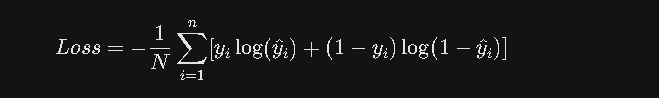

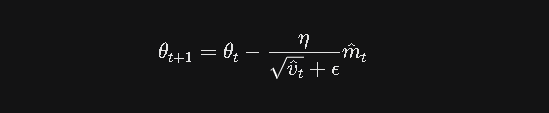

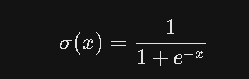


🚀 Treinando e gerando diagnóstico...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.7519 - loss: 0.4900 - val_accuracy: 0.8640 - val_loss: 0.3439
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.8963 - loss: 0.2701 - val_accuracy: 0.8656 - val_loss: 0.3427
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.9003 - loss: 0.2580 - val_accuracy: 0.8522 - val_loss: 0.3488
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9416 - loss: 0.1631 - val_accuracy: 0.8790 - val_loss: 0.3842
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9588 - loss: 0.1168 - val_accuracy: 0.8734 - val_loss: 0.3969
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9675 - loss: 0.0917 - val_accuracy: 0.8638 - val_loss: 0.4166
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9736 - loss: 0.0761 - val_accuracy: 0.8564 - val_loss: 0.5773
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9820 - loss: 0.0531 - val_accuracy: 0.866

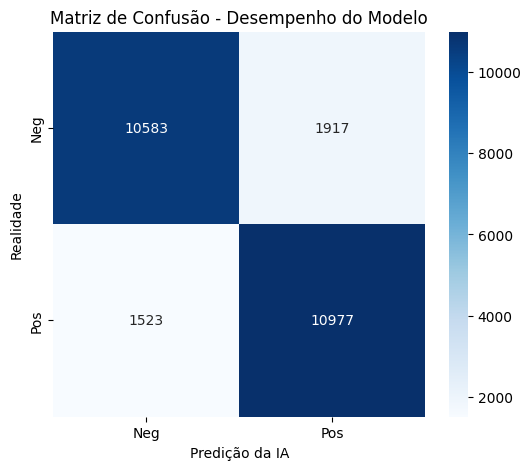


✅ Acurácia Final: 86.24%


In [58]:
from sklearn.metrics import confusion_matrix # Mede o desempenho do classificador
import seaborn as sns # Biblioteca para visualização de dados (gráficos estatísticos)

# 3. MODELO E TREINAMENTO COM MATRIZ DE CONFUSÃO
# Cria o modelo da rede neural sequencial
modelo_imdb = models.Sequential([
    # Camada Embedding: Converte palavras (números) em vetores densos (representação contínua)
    # input_length (depreciado): indica o comprimento esperado das sequências de entrada
    layers.Embedding(max_features, 128, input_length=maxlen),
    # Transforma palavras em coordenadas matemáticas para a IA entender que "bom" e "ótimo" são parecidos
    layers.SpatialDropout1D(0.3),
    # LSTM: Long Short-Term Memory, camada para processar sequências e capturar dependências de longo prazo
    layers.LSTM(128, dropout=0.2),
    # Dense: Camada totalmente conectada com função de ativação ReLU (Rectified Linear Unit)
    layers.Dense(128, activation='relu'),
    # Dropout: Desativa aleatoriamente neurônios para evitar overfitting
    layers.Dropout(0.4),
    # (evita o overfitting)
    layers.Dense(1, activation='sigmoid')
])

modelo_imdb.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\n🚀 Treinando e gerando diagnóstico...")
# Treina o modelo nos dados de treinamento

history = modelo_imdb.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

# --- GERANDO A MATRIZ DE CONFUSÃO (O QUADRADO) ---
# Faz previsões nos dados de teste e converte probabilidades em classes binárias (0 ou 1)
y_pred = (modelo_imdb.predict(x_test) > 0.5).astype("int32")
# Calcula a matriz de confusão comparando previsões com rótulos reais
cm = confusion_matrix(y_test, y_pred)

# Cria um gráfico da matriz de confusão usando Seaborn e Matplotlib
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
plt.title('Matriz de Confusão - Desempenho do Modelo')
plt.xlabel('Predição da IA')
plt.ylabel('Realidade')
plt.show()

# Avalia o modelo nos dados de teste para obter a perda e acurácia final
loss, acc = modelo_imdb.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Acurácia Final: {acc*100:.2f}%")

### 4. 📊 Exemplos de Classificações do Modelo

Para entender melhor como o modelo está classificando as críticas, vamos visualizar alguns exemplos. Abaixo, serão mostradas 10 críticas que o modelo previu como 'Negativas' e 10 que previu como 'Positivas', juntamente com seus rótulos reais (`Realidade`).

- **Funções/Bibliotecas**: `keras.datasets.imdb.get_word_index` para mapeamento de palavras, `numpy.where` para índices, `deep_translator.GoogleTranslator` para tradução, `pandas.DataFrame` e `display` para exibição.

In [59]:
# 4. EXEMPLOS DE CLASSIFICAÇÕES DO MODELO (NEGATIVAS E POSITIVAS)

# Obtém o mapeamento de palavras para índices numéricos do dataset IMDB
word_index = datasets.imdb.get_word_index()
# Cria um dicionário inverso para converter os índices numéricos de volta para palavras
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Função para decodificar uma sequência numérica de volta para texto legível
def decode_review(text_sequence):
    # Mapeia os índices de palavras para as palavras reais, ajustando o deslocamento de +3
    word_map = {}
    for original_idx, word in reverse_word_index.items():
        word_map[original_idx + 3] = word

    decoded_words = []
    for i in text_sequence:
        if i == 0:  # Ignora tokens de preenchimento (<PAD>)
            continue
        elif i == 1:  # Ignora tokens de início (<START>)
            continue
        elif i == 2:  # Representa palavras desconhecidas (<UNK>) com '...'
            decoded_words.append("...")
        else:
            # Adiciona a palavra mapeada ou '?' se não encontrada
            decoded_words.append(word_map.get(i, '?'))

    # Junta as palavras para formar a crítica, removendo espaços extras
    return ' '.join(decoded_words).strip()

# Faz as previsões do modelo (se ainda não tiverem sido feitas)
if 'y_pred' not in locals():
    y_pred = (modelo_imdb.predict(x_test, verbose=0) > 0.5).astype("int32")

# --- FIX: Define negative_predictions_indices and positive_predictions_indices ---
# Encontra os índices das previsões negativas (0) e positivas (1) no conjunto de teste
negative_predictions_indices = np.where(y_pred.flatten() == 0)[0]
positive_predictions_indices = np.where(y_pred.flatten() == 1)[0]
# ---------------------------------------------------------------------------------

# Inicializa o tradutor do Google de inglês para português
translator_for_samples = GoogleTranslator(source='en', target='pt')

# Define o intervalo de comprimento de caracteres desejado para as críticas exibidas
min_review_char_len = 50
max_review_char_len = 250

# --- Amostras de 5 Críticas Preditas como NEGATIVAS (com filtro e tradução) ---
print("\n--- 5 Críticas Preditas como NEGATIVAS (Comprimento Filtrado e Tradução) ---")
feedback_samples_neg = []
for idx in negative_predictions_indices:
    original_review_en = decode_review(x_test[idx])
    # Filtra críticas pelo comprimento definido
    if min_review_char_len <= len(original_review_en) <= max_review_char_len:
        # Traduz a crítica para o português
        try:
            translated_review_pt = translator_for_samples.translate(original_review_en)
        except Exception as e:
            translated_review_pt = f"Erro na tradução: {e}"

        # Adiciona os detalhes da crítica à lista
        feedback_samples_neg.append({
            "Crítica (EN)": original_review_en,
            "Crítica (PT)": translated_review_pt,
            "Predição IA": "Negativa",
            "Realidade": "Negativa" if y_test[idx] == 0 else "Positiva"
        })
    if len(feedback_samples_neg) >= 5: # Limita a 5 amostras
        break

# Cria um DataFrame Pandas para exibir as amostras negativas
df_neg_samples = pd.DataFrame(feedback_samples_neg)
display(df_neg_samples)

# --- Amostras de 5 Críticas Preditas como POSITIVAS (com filtro e tradução) ---
print("\n--- 5 Críticas Preditas como POSITIVAS (Comprimento Filtrado e Tradução) ---")
feedback_samples_pos = []
for idx in positive_predictions_indices:
    original_review_en = decode_review(x_test[idx])
    # Filtra críticas pelo comprimento definido
    if min_review_char_len <= len(original_review_en) <= max_review_char_len:
        # Traduz a crítica para o português
        try:
            translated_review_pt = translator_for_samples.translate(original_review_en)
        except Exception as e:
            translated_review_pt = f"Erro na tradução: {e}"

        # Adiciona os detalhes da crítica à lista
        feedback_samples_pos.append({
            "Crítica (EN)": original_review_en,
            "Crítica (PT)": translated_review_pt,
            "Predição IA": "Positiva",
            "Realidade": "Negativa" if y_test[idx] == 0 else "Positiva"
        })
    if len(feedback_samples_pos) >= 5: # Limita a 5 amostras
        break

# Cria um DataFrame Pandas para exibir as amostras positivas
df_pos_samples = pd.DataFrame(feedback_samples_pos)
display(df_pos_samples)


--- 5 Críticas Preditas como NEGATIVAS (Comprimento Filtrado e Tradução) ---


,Crítica (EN),Crítica (PT),Predição IA,Realidade
0,i've seen ... brown coffy friday foster ... an...,eu já vi... marrom coffy sexta-feira adotiva.....,Negativa,Negativa
1,the premise of this film is the only thing wor...,a premissa deste filme é a única coisa que val...,Negativa,Negativa
2,i gave this a 2 and it only avoided a 1 becaus...,dei nota 2 e só evitei nota 1 por causa das ri...,Negativa,Negativa
3,although it's been hailed as a comedy drama i ...,embora tenha sido aclamado como uma comédia dr...,Negativa,Negativa
4,what a waste of talent a very poor semi cohere...,"que desperdício de talento, um roteiro muito p...",Negativa,Negativa



--- 5 Críticas Preditas como POSITIVAS (Comprimento Filtrado e Tradução) ---


,Crítica (EN),Crítica (PT),Predição IA,Realidade
0,i saw this movie many years ago and just for k...,eu vi esse filme há muitos anos e só por diver...,Positiva,Negativa
1,i'm not a fan of scratching but i really dug t...,"não sou fã de scratch, mas adorei esse filme, ...",Positiva,Positiva
2,more suspenseful more subtle much much more di...,mais suspense mais sutil muito mais perturbador,Positiva,Negativa
3,1st watched 8 31 1996 dir tim robbins very tho...,Assistido pela primeira vez em 31 de agosto de...,Positiva,Positiva
4,this is a great movie for all corey ... fans t...,este é um ótimo filme para todos os fãs de Cor...,Positiva,Positiva


### 4.1. Detalhes da Exibição de Críticas Negativas

A célula abaixo ajusta as opções de exibição do Pandas para que você possa visualizar o conteúdo completo das críticas negativas de exemplo, sem truncamento. Isso é útil para inspecionar os detalhes de cada crítica.

In [60]:
# 4 Exibição de Críticas Negativas
pd.set_option('display.max_columns', None) # Exibe todas as colunas
pd.set_option('display.max_rows', None) # Exibe todas as linhas
pd.set_option('display.width', None) # Ajusta a largura de exibição
pd.set_option('display.max_colwidth', None) # Exibe o conteúdo completo das colunas
display(df_neg_samples) # Exibe o DataFrame de amostras negativas com as opções aplicadas
pd.reset_option('display.max_columns') # Reseta as opções de exibição de colunas
pd.reset_option('display.max_rows') # Reseta as opções de exibição de linhas
pd.reset_option('display.width') # Reseta a largura de exibição
pd.reset_option('display.max_colwidth') # Reseta o comprimento máximo das colunas

,Crítica (EN),Crítica (PT),Predição IA,Realidade
0,i've seen ... brown coffy friday foster ... and black mama white mama of these this is pam ... worst movie poor acting bad script boring action scenes there's just nothing there avoid this and rent friday foster coffy or ... brown instead,eu já vi... marrom coffy sexta-feira adotiva... e mamãe negra mamãe branca dessas esta é pam... pior filme má atuação roteiro ruim cenas de ação chatas não há nada lá evite isso e alugue sexta-feira adotiva coffy ou... marrom em vez disso,Negativa,Negativa
1,the premise of this film is the only thing worthwhile it is very poorly made but the idea was clever if not entirely original it's a shame the other aspects of the film weren't better the acting is especially bad,"a premissa deste filme é a única coisa que vale a pena, é muito mal feito, mas a ideia foi inteligente, se não totalmente original, é uma pena que os outros aspectos do filme não tenham sido melhores, a atuação é especialmente ruim",Negativa,Negativa
2,i gave this a 2 and it only avoided a 1 because of the occasional unintentional laugh the film is excruciatingly boring and incredibly cheap it's even worse if you know anything at all about the fantastic four,dei nota 2 e só evitei nota 1 por causa das risadas ocasionais e não intencionais o filme é terrivelmente chato e incrivelmente barato é ainda pior se você souber alguma coisa sobre o quatro fantástico,Negativa,Negativa
3,although it's been hailed as a comedy drama i found to be mostly depressing it's hard to imagine how spike lee could look back ... on so much chaos petty cruelty ... and mean ...,"embora tenha sido aclamado como uma comédia dramática, achei que era principalmente deprimente, é difícil imaginar como Spike Lee poderia olhar para trás... para tanto caos, crueldade mesquinha... e maldade...",Negativa,Negativa
4,what a waste of talent a very poor semi coherent script ... this film rather unimaginative direction too some very faint echoes of ... here but it just doesn't come off,"que desperdício de talento, um roteiro muito pobre e semi-coerente... este filme tem uma direção pouco imaginativa e também alguns ecos muito fracos de... aqui, mas simplesmente não sai",Negativa,Negativa


### 5. ☁️ Nuvem de Palavras das Críticas de Exemplo (Separadas por Sentimento)

Aqui estão as nuvens de palavras geradas a partir das 5 críticas de exemplo positivas e 5 negativas que foram classificadas e exibidas anteriormente.

--- Nuvem de Palavras - 5 Críticas NEGATIVAS de Exemplo ---


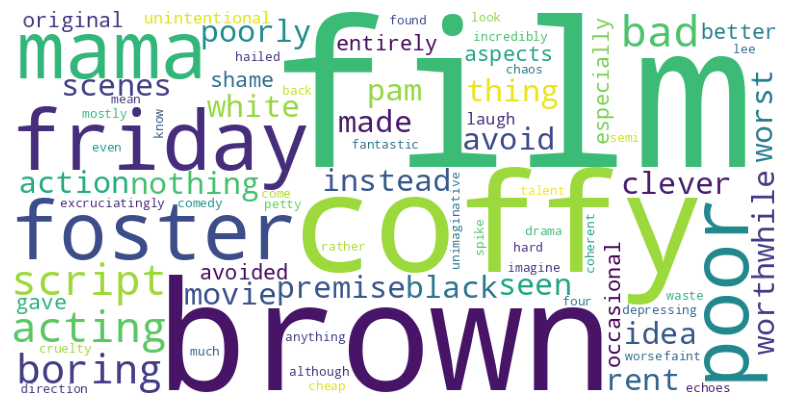


--- Nuvem de Palavras - 5 Críticas POSITIVAS de Exemplo ---


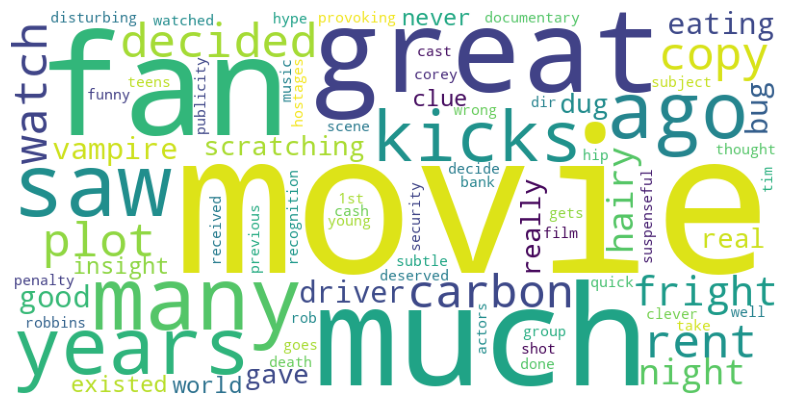

In [61]:
# 5.  Nuvem de Palavras
# As variáveis df_neg_samples e df_pos_samples já devem estar definidas a partir da execução da célula 8085ec93.

# Extrai o texto das críticas negativas traduzidas para inglês
negative_sample_words_text = " ".join(df_neg_samples['Crítica (EN)'].tolist())

# Extrai o texto das críticas positivas traduzidas para inglês
positive_sample_words_text = " ".join(df_pos_samples['Crítica (EN)'].tolist())

print("--- Nuvem de Palavras - 5 Críticas NEGATIVAS de Exemplo ---")
if negative_sample_words_text:
    wc_neg_samples = WordCloud(width=800, height=400, background_color="white").generate(negative_sample_words_text)
    plt.figure(figsize=(10, 5)); plt.imshow(wc_neg_samples); plt.axis("off"); plt.show()
else:
    print("Não há críticas NEGATIVAS de exemplo para gerar a nuvem de palavras.")

print("\n--- Nuvem de Palavras - 5 Críticas POSITIVAS de Exemplo ---")
if positive_sample_words_text:
    wc_pos_samples = WordCloud(width=800, height=400, background_color="white").generate(positive_sample_words_text)
    plt.figure(figsize=(10, 5)); plt.imshow(wc_pos_samples); plt.axis("off"); plt.show()
else:
    print("Não há críticas POSITIVAS de exemplo para gerar a nuvem de palavras.")

In [62]:
# Garante que deep_translator esteja instalado (útil após reinicializações do kernel)
!pip install deep_translator

import time # Funções relacionadas a tempo
import sys # Funções e variáveis do sistema Python
import pandas as pd # Para manipulação e análise de dados (DataFrames)
from PIL import Image # Adicionar esta importação para Image.open
from tensorflow.keras import datasets, preprocessing # Importar datasets e preprocessing
from deep_translator import GoogleTranslator # Para traduzir textos
from wordcloud import WordCloud # Para criar nuvens de palavras
from IPython.display import display, clear_output # Utilidades do Colab para exibição e limpeza de saída

# Define os parâmetros max_features e maxlen (necessário para o escopo da função)
max_features = 15000
maxlen = 400

# Função para gerar o veredito final com base nas críticas
def gerar_veredito(df_feedbacks):
    total_reviews = len(df_feedbacks) # Calcula o total de críticas
    positive_reviews = df_feedbacks[df_feedbacks['Sentimento IA'] == 'POSITIVA'].shape[0] # Conta críticas positivas
    negative_reviews = df_feedbacks[df_feedbacks['Sentimento IA'] == 'NEGATIVA'].shape[0] # Conta críticas negativas

    print("\n--- VEREDITO FINAL ---")
    print(f"Total de Críticas Analisadas: {total_reviews}")
    print(f"Críticas Positivas: {positive_reviews} ({positive_reviews/total_reviews*100:.2f}%) ")
    print(f"Críticas Negativas: {negative_reviews} ({negative_reviews/total_reviews*100:.2f}%) ")

    # Determina o veredito geral
    if positive_reviews > negative_reviews:
        print("🎉 Veredito: A maioria das críticas é POSITIVA! O projeto parece ser bem recebido.")
    elif negative_reviews > positive_reviews:
        print("😔 Veredito: A maioria das críticas é NEGATIVA! O projeto pode precisar de atenção.")
    else:
        print("⚖️ Veredito: Há um equilíbrio entre críticas POSITIVAS e NEGATIVAS. Opinião dividida.")

# Função principal para analisar críticas com imagem e dashboard
def analisar_com_imagem_e_criticas(caminho_img):
    img = Image.open(caminho_img) # Abre a imagem do caminho fornecido

    feedbacks = [] # Lista para armazenar os feedbacks
    print(f"✅ Imagem detectada! Agora, por favor, digite as 3 críticas.")
    print("⚠️ O campo de digitação aparecerá logo abaixo:")

    translator = GoogleTranslator(source='pt', target='en') # Inicializa o tradutor de PT para EN
    word_index = datasets.imdb.get_word_index() # Obtém o índice de palavras do IMDB

    for i in range(1, 4): # Loop para coletar 3 críticas
        print(f"\n--- Crítico {i}/3 ---")
        sys.stdout.flush() # Força a exibição do print antes do input

        nome = input(f"👤 Nome do Crítico {i}: ") # Pede o nome do crítico
        while True:
            opiniao_pt = input(f"💬 Opinião em Português: ") # Pede a opinião em português
            # Verifica se a opinião contém números
            if any(char.isdigit() for char in opiniao_pt):
                print("❌ Erro: Críticas não podem conter números. Por favor, digite novamente.")
            else:
                break

        # Processamento da IA
        opiniao_en = translator.translate(opiniao_pt) # Traduz a opinião para inglês
        print(f"🇺🇸 Tradução (EN): {opiniao_en}") # Exibe a tradução em inglês
        palavras = opiniao_en.lower().split() # Converte a opinião para minúsculas e divide em palavras
        # Converte palavras para sequências numéricas usando word_index
        sequencia = [word_index.get(p, 0) + 3 for p in palavras if word_index.get(p, 0) < max_features]
        # Padroniza (preenche/trunca) a sequência numérica para o `maxlen`
        pad = preprocessing.sequence.pad_sequences([sequencia], maxlen=maxlen)

        score = modelo_imdb.predict(pad, verbose=0)[0][0] # O modelo prevê a pontuação de sentimento
        sentimento = "POSITIVA" if score > 0.5 else "NEGATIVA" # Classifica o sentimento

        # Adiciona os detalhes da crítica aos feedbacks
        feedbacks.append({
            "Usuário": nome,
            "Opinião Original (PT)": (opiniao_pt[:100] + '...') if len(opiniao_pt) > 100 else opiniao_pt,
            "Tradução (EN)": (opiniao_en[:100] + '...') if len(opiniao_en) > 100 else opiniao_en,
            "Sentimento IA": sentimento,
            "Confiança": f"{score*100:.2f}%"
        })

    # --- EXIBIÇÃO ORGANIZADA DOS RESULTADOS ---
    clear_output(wait=True) # Limpa a saída para uma exibição organizada

    # 1. Pôster do Filme
    plt.figure(figsize=(4, 5)) # Cria uma figura para a imagem
    plt.imshow(img); plt.axis('off'); plt.title("🎞️ PROJETO ANALISADO") # Exibe a imagem
    plt.show() # Mostra a imagem

    # 2. Tabela de Críticas (Dashboard)
    print("\n📊 DASHBOARD DE SENTIMENTOS:")
    df = pd.DataFrame(feedbacks) # Cria um DataFrame a partir dos feedbacks
    # Define opção do Pandas para exibir o conteúdo completo das colunas (sem truncar)
    pd.set_option('display.max_colwidth', None)
    display(df) # Exibe o DataFrame
    # Reseta a opção do Pandas para o padrão após a exibição
    pd.reset_option('display.max_colwidth')

    # 3. Veredito Final
    gerar_veredito(df) # Chama a função para gerar o veredito final

    # 4. Nuvem de Palavras (separadas por sentimento)
    print("\n☁️ RESUMO VISUAL (TERMOS MAIS USADOS):")
    positive_words_text = " ".join([f['Tradução (EN)'] for f in feedbacks if f['Sentimento IA'] == 'POSITIVA'])
    negative_words_text = " ".join([f['Tradução (EN)'] for f in feedbacks if f['Sentimento IA'] == 'NEGATIVA'])

    if positive_words_text:
        print("\n--- Nuvem de Palavras - Críticas POSITIVAS ---")
        wc_pos = WordCloud(width=800, height=400, background_color="white").generate(positive_words_text)
        plt.figure(figsize=(10, 5)); plt.imshow(wc_pos); plt.axis("off"); plt.show()
    else:
        print("Não há críticas POSITIVAS para gerar a nuvem de palavras.")

    if negative_words_text:
        print("\n--- Nuvem de Palavras - Críticas NEGATIVAS ---")
        wc_neg = WordCloud(width=800, height=400, background_color="white").generate(negative_words_text)
        plt.figure(figsize=(10, 5)); plt.imshow(wc_neg); plt.axis("off"); plt.show()
    else:
        print("Não há críticas NEGATIVAS para gerar a nuvem de palavras.")

### 6. ▶️ Início do Sistema de Análise Interativa

- **Início limpo**: Limpa o console (`IPython.display.clear_output`).
- **Upload de imagem**: Solicita ao usuário o upload de uma imagem (`google.colab.files.upload`).
- **Inicia análise**: Chama `analisar_com_imagem_e_criticas` para coletar e analisar sentimentos.

Função interativa: `analisar_com_imagem_e_criticas` solicita imagem e 3 críticas em português. Processamento: Críticas traduzidas (`deep_translator.GoogleTranslator`), analisadas (`modelo_imdb.predict`). Resultados: Exibe pôster (`PIL.Image`, `matplotlib.pyplot`), dashboard de críticas (`pandas.DataFrame`, `pd.set_option`, `gerar_veredito`) e nuvem de palavras (`wordcloud.WordCloud`)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127902 (\N{FILM FRAMES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


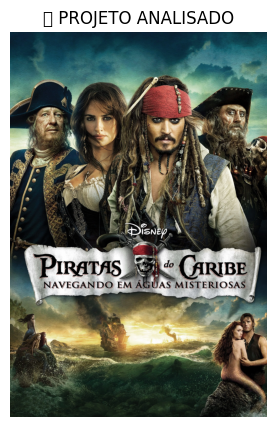


📊 DASHBOARD DE SENTIMENTOS:


,Usuário,Opinião Original (PT),Tradução (EN),Sentimento IA,Confiança
0,1,dasdas,dasdas,POSITIVA,52.01%
1,2,bom,good,POSITIVA,63.73%
2,3,ruim,bad,NEGATIVA,46.68%



--- VEREDITO FINAL ---
Total de Críticas Analisadas: 3
Críticas Positivas: 2 (66.67%) 
Críticas Negativas: 1 (33.33%) 
🎉 Veredito: A maioria das críticas é POSITIVA! O projeto parece ser bem recebido.

☁️ RESUMO VISUAL (TERMOS MAIS USADOS):

--- Nuvem de Palavras - Críticas POSITIVAS ---


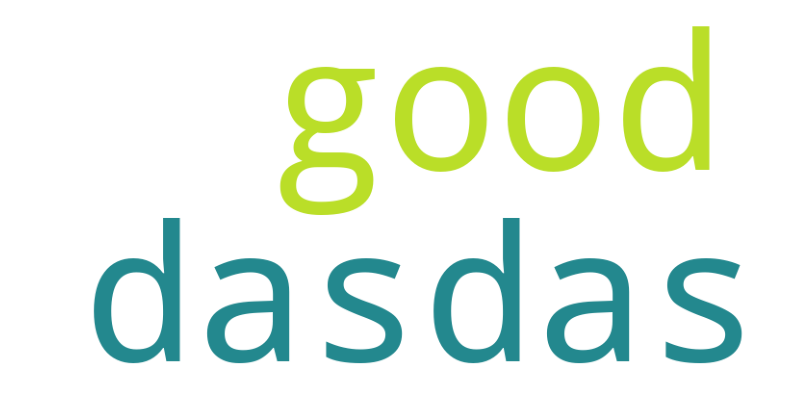


--- Nuvem de Palavras - Críticas NEGATIVAS ---


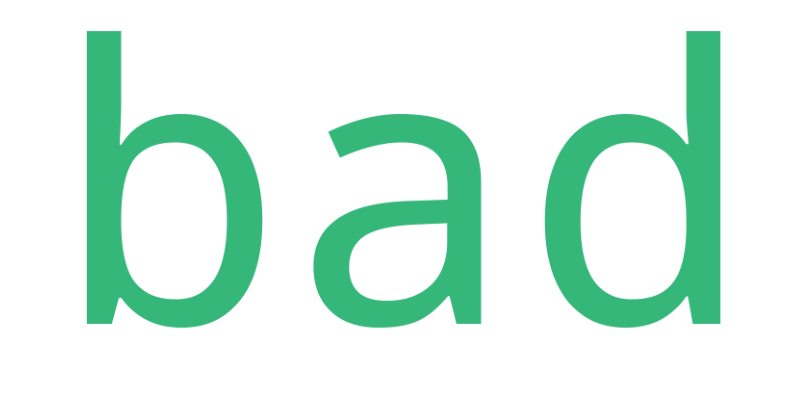

In [63]:
# 6. INICIAR SISTEMA

# Limpa o console para começar do zero
clear_output()
print("📁 PASSO 1: Por favor, carregue a imagem do projeto para análise. Isso abrirá uma janela para você selecionar o arquivo.")

# Permite o upload de arquivos via interface do Colab
uploaded = files.upload()

# Pega o nome do arquivo da imagem carregada (assumindo que apenas um arquivo será carregado)
if uploaded:
    nome_arquivo_imagem = next(iter(uploaded)) # Pega a chave do primeiro item no dicionário
    print(f"✅ Imagem '{nome_arquivo_imagem}' carregada com sucesso!")
    # Chama a função principal de análise com o nome do arquivo da imagem
    analisar_com_imagem_e_criticas(nome_arquivo_imagem)
else:
    print("❌ Nenhum arquivo foi carregado. Por favor, tente novamente.")